In [ ]:
!pip install qiskit
!pip install qiskit qiskit-aer
!pip install pylatexenc

In [1]:
# Import libraries
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

%matplotlib inline

In [2]:
# Step 1: Create a quantum circuit with 2 qubits and 2 classical bits
qc = QuantumCircuit(2, 2)

In [3]:
# Step 2: Apply gates to demonstrate tensor product states
qc.x(0)  # Apply X gate on qubit 0 → |10>

In [4]:
# Step 3: Measure both qubits
qc.measure([0, 1], [0, 1])

In [5]:
# Step 4: Use AerSimulator (new standard in Qiskit 2.x)
simulator = AerSimulator()

# Transpile the circuit for the simulator
from qiskit import transpile
compiled_circuit = transpile(qc, simulator)

# Run the circuit
job = simulator.run(compiled_circuit, shots=1024)
result = job.result()

# Get counts
counts = result.get_counts()

Measurement Results: {'01': 1024}


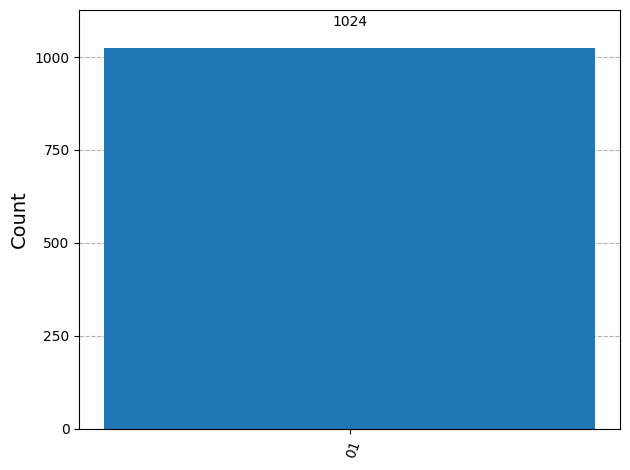

In [6]:
# Step 5: Display circuit and results
print("Measurement Results:", counts)
qc.draw('text')
plt.show()
plot_histogram(counts)
plt.show()

Measurement Results: {'10': 252, '01': 257, '00': 257, '11': 258}


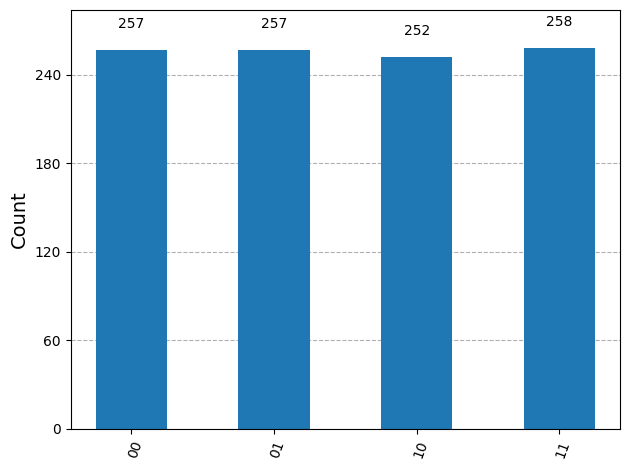

In [7]:
"""
Task 1: Change Gate Combination

Apply a Hadamard gate on both qubits and observe the output probabilities.
What pattern do you notice in the histogram?
"""

qc = QuantumCircuit(2, 2)
qc.h(0)
qc.h(1)

qc.measure([0, 1], [0, 1])

simulator = AerSimulator()
compiled_circuit = transpile(qc, simulator)
job = simulator.run(compiled_circuit, shots=1024)
result = job.result()
counts = result.get_counts()

print("Measurement Results:", counts)
qc.draw('text')
plt.show()
plot_histogram(counts)
plt.show()

Measurement Results: {'10': 1024}


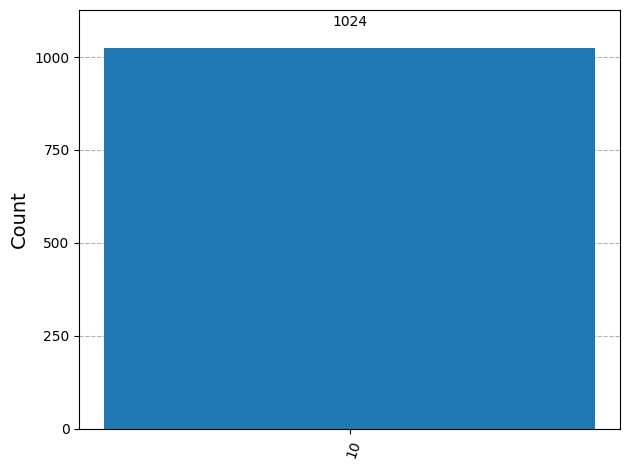

In [8]:
"""
Task 2: Swap Qubit Roles

Apply an X gate on the second qubit instead of the first.
Compare the output with the original circuit.
"""

qc = QuantumCircuit(2, 2)
qc.x(1)
qc.measure([0, 1], [0, 1])

simulator = AerSimulator()
compiled_circuit = transpile(qc, simulator)
job = simulator.run(compiled_circuit, shots=1024)
result = job.result()
counts = result.get_counts()

print("Measurement Results:", counts)
qc.draw('text')
plt.show()
plot_histogram(counts)
plt.show()

Measurement Results: {'11': 538, '00': 486}


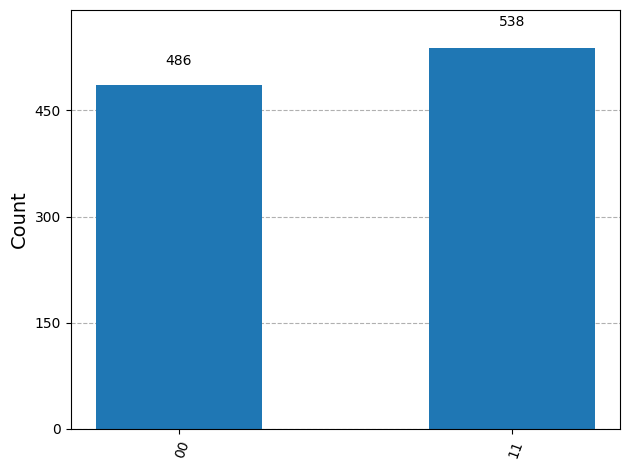

In [9]:
"""
Task 3: Add a CNOT Gate

Add qc.cx(0, 1) after the Hadamard gate.
What kind of state does this create? (Hint: entanglement)
"""

qc = QuantumCircuit(2, 2)
qc.h(0)
# qc.h(1)
qc.cx(0, 1)

qc.measure([0, 1], [0, 1])

simulator = AerSimulator()
compiled_circuit = transpile(qc, simulator)
job = simulator.run(compiled_circuit, shots=1024)
result = job.result()
counts = result.get_counts()

print("Measurement Results:", counts)
qc.draw('text')
plt.show()
plot_histogram(counts)
plt.show()

Measurement Results: {'11': 999, '00': 1026, '01': 1089, '10': 982}


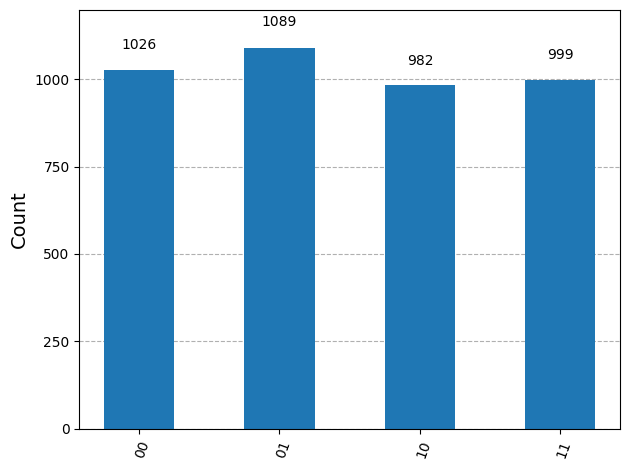

In [10]:
"""
Task 4: Increase Measurement Shots

Change the number of shots from 1024 to 4096 in the execute() function.
Does the distribution become more stable?
"""

qc = QuantumCircuit(2, 2)
qc.h(0)
qc.h(1)

qc.measure([0, 1], [0, 1])

simulator = AerSimulator()
compiled_circuit = transpile(qc, simulator)
job = simulator.run(compiled_circuit, shots=4096)
result = job.result()
counts = result.get_counts()

print("Measurement Results:", counts)
qc.draw('text')
plt.show()
plot_histogram(counts)
plt.show()

--- Visualization BEFORE Measurement ---
Statevector: Statevector([0.5+0.j, 0.5+0.j, 0.5+0.j, 0.5+0.j],
            dims=(2, 2))


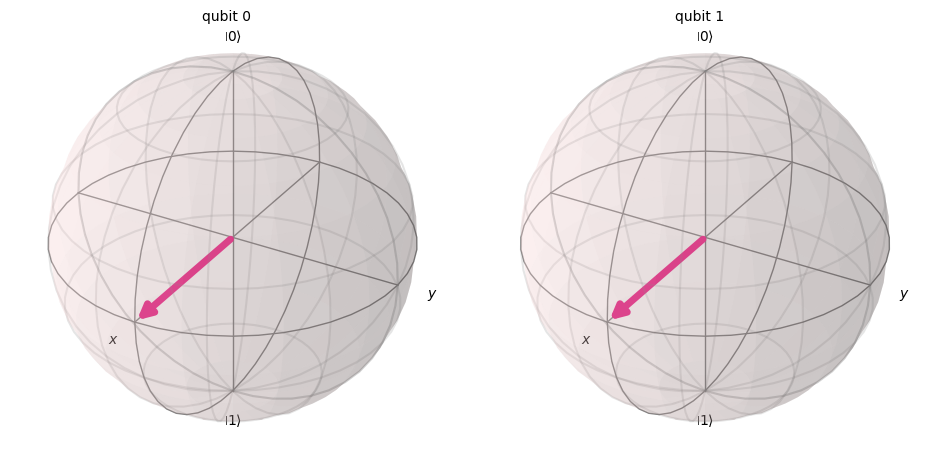


--- Visualization AFTER Measurement ---
Counts: {'00': 257, '10': 276, '01': 251, '11': 240}


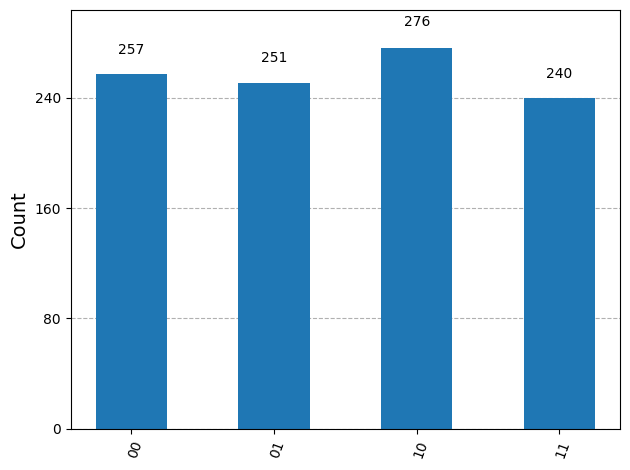

--- Visualization of the classical state |00> ---


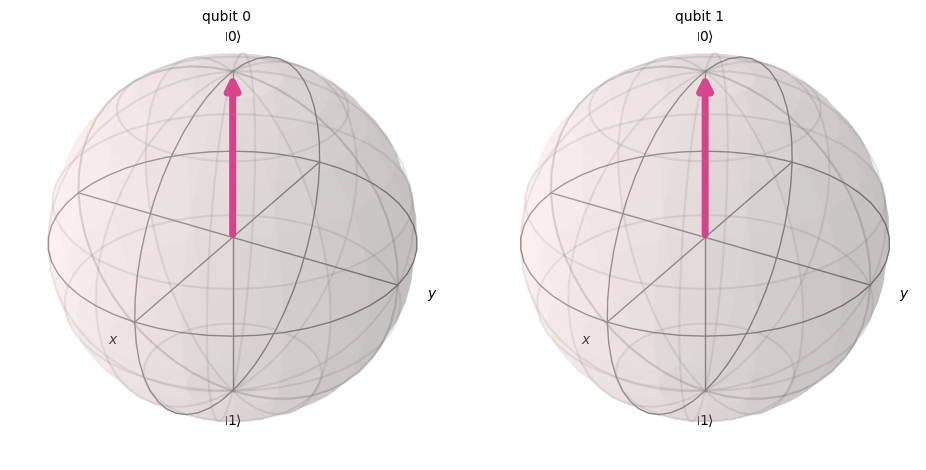

--- Visualization of the classical state |01> ---


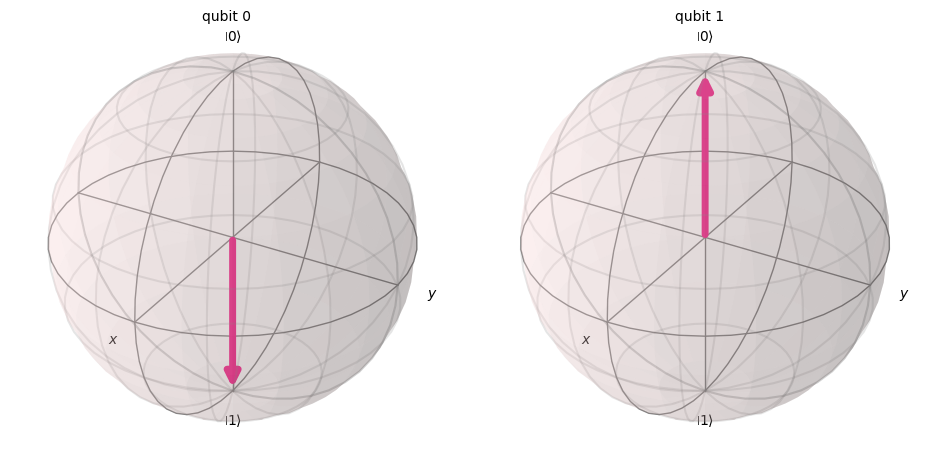

--- Visualization of the classical state |10> ---


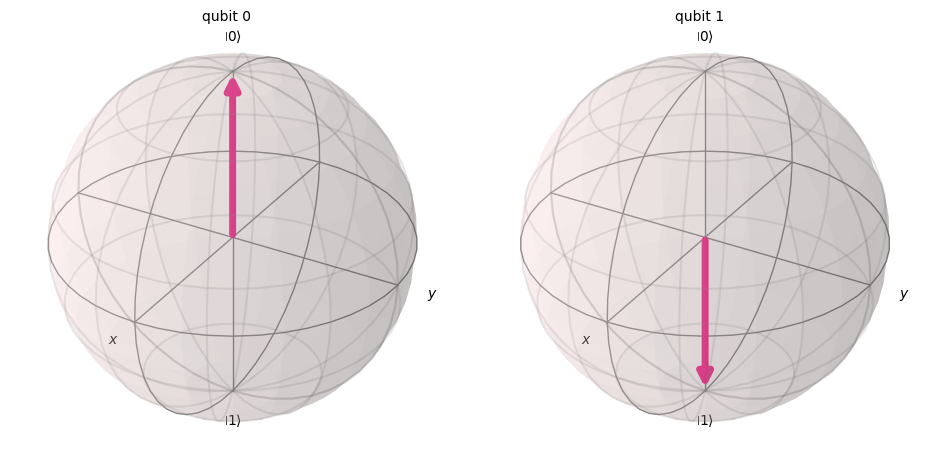

--- Visualization of the classical state |11> ---


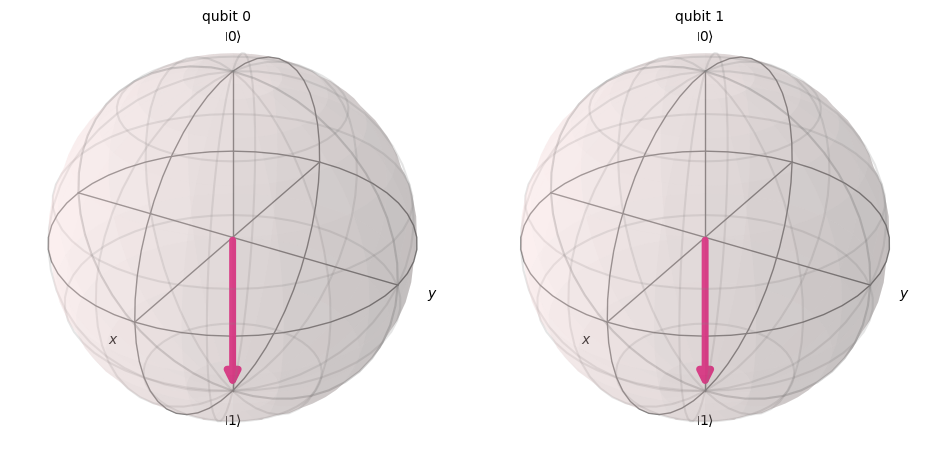

In [11]:
"""
Task 5: Add a New Visualization

Use plot_bloch_multivector to visualize the combined state of both qubits.
Observe how the Bloch sphere changes before and after measurement.
"""

from qiskit.visualization import plot_bloch_multivector

qc = QuantumCircuit(2, 2)
qc.h(0)
qc.h(1)

qc.save_statevector()

simulator = AerSimulator()
job = simulator.run(qc)
result = job.result()
statevector = result.get_statevector()

print("--- Visualization BEFORE Measurement ---")
print("Statevector:", statevector)
plot_bloch_multivector(statevector)
plt.show()

qc.measure([0, 1], [0, 1])

compiled_circuit = transpile(qc, simulator)
job_measure = simulator.run(compiled_circuit, shots=1024)
counts = job_measure.result().get_counts()

print("\n--- Visualization AFTER Measurement ---")
print("Counts:", counts)
plot_histogram(counts)
plt.show()

state_00 = [1, 0, 0, 0]
print("--- Visualization of the classical state |00> ---")
plot_bloch_multivector(state_00)
plt.show()

state_01 = [0, 1, 0, 0]
print("--- Visualization of the classical state |01> ---")
plot_bloch_multivector(state_01)
plt.show()

state = [0, 0, 1, 0] 
print("--- Visualization of the classical state |10> ---")
plot_bloch_multivector(state)
plt.show()

state_11 = [0, 0, 0, 1]
print("--- Visualization of the classical state |11> ---")
plot_bloch_multivector(state_11)
plt.show()